# Exploration des événements et de leur impact sur les ventes par magasin

Dans le notebook précédent, nous avons analysé les disparités de volume et de comportement entre les 10 magasins. Nous avons notamment observé que les trois états suivent la même dynamique temporelle avec des pics et creux simultanés, ce qui suggère que certains facteurs externes communs influencent la demande.

Ce notebook a pour objectif d'identifier et de quantifier ces facteurs. On commence par analyser la saisonnalité mensuelle pour déterminer si les mois expliquent les variations de ventes, puis on se concentre sur les événements ponctuels du calendrier américain et leur impact sur les ventes, d'abord de façon globale puis magasin par magasin.

Ces observations alimenteront directement notre partie Recherche Opérationnelle en fournissant des règles quantifiées pour l'optimisation des stocks (contraintes etc)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


sales    = pd.read_csv('/Users/maelys_thr/Desktop/sales_train_evaluation.csv')
calendar = pd.read_csv('/Users/maelys_thr/Desktop/calendar.csv')

calendar["date"] = pd.to_datetime(calendar["date"])
day_cols         = [c for c in sales.columns if c.startswith('d_')]
day_to_date      = dict(zip(calendar['d'], calendar['date']))

print(f"Période : {calendar['date'].min().date()} - {calendar['date'].max().date()}")
print(f"Nombre d'événements : {calendar['event_name_1'].dropna().nunique()}")
print(f"Événements disponibles : {sorted(calendar['event_name_1'].dropna().unique())}")

Période : 2011-01-29 - 2016-06-19
Nombre d'événements : 30
Événements disponibles : ['Chanukah End', 'Christmas', 'Cinco De Mayo', 'ColumbusDay', 'Easter', 'Eid al-Fitr', 'EidAlAdha', "Father's day", 'Halloween', 'IndependenceDay', 'LaborDay', 'LentStart', 'LentWeek2', 'MartinLutherKingDay', 'MemorialDay', "Mother's day", 'NBAFinalsEnd', 'NBAFinalsStart', 'NewYear', 'OrthodoxChristmas', 'OrthodoxEaster', 'Pesach End', 'PresidentsDay', 'Purim End', 'Ramadan starts', 'StPatricksDay', 'SuperBowl', 'Thanksgiving', 'ValentinesDay', 'VeteransDay']


## 1. Saisonnalité mensuelle des ventes

Avant d'analyser les événements ponctuels, on vérifie d'abord si les mois de l'année influencent les ventes au sein des 10 magasins. Si la saisonnalité mensuelle est faible, cela confirmera que ce sont les événements ponctuels qui créent les vraies variations.

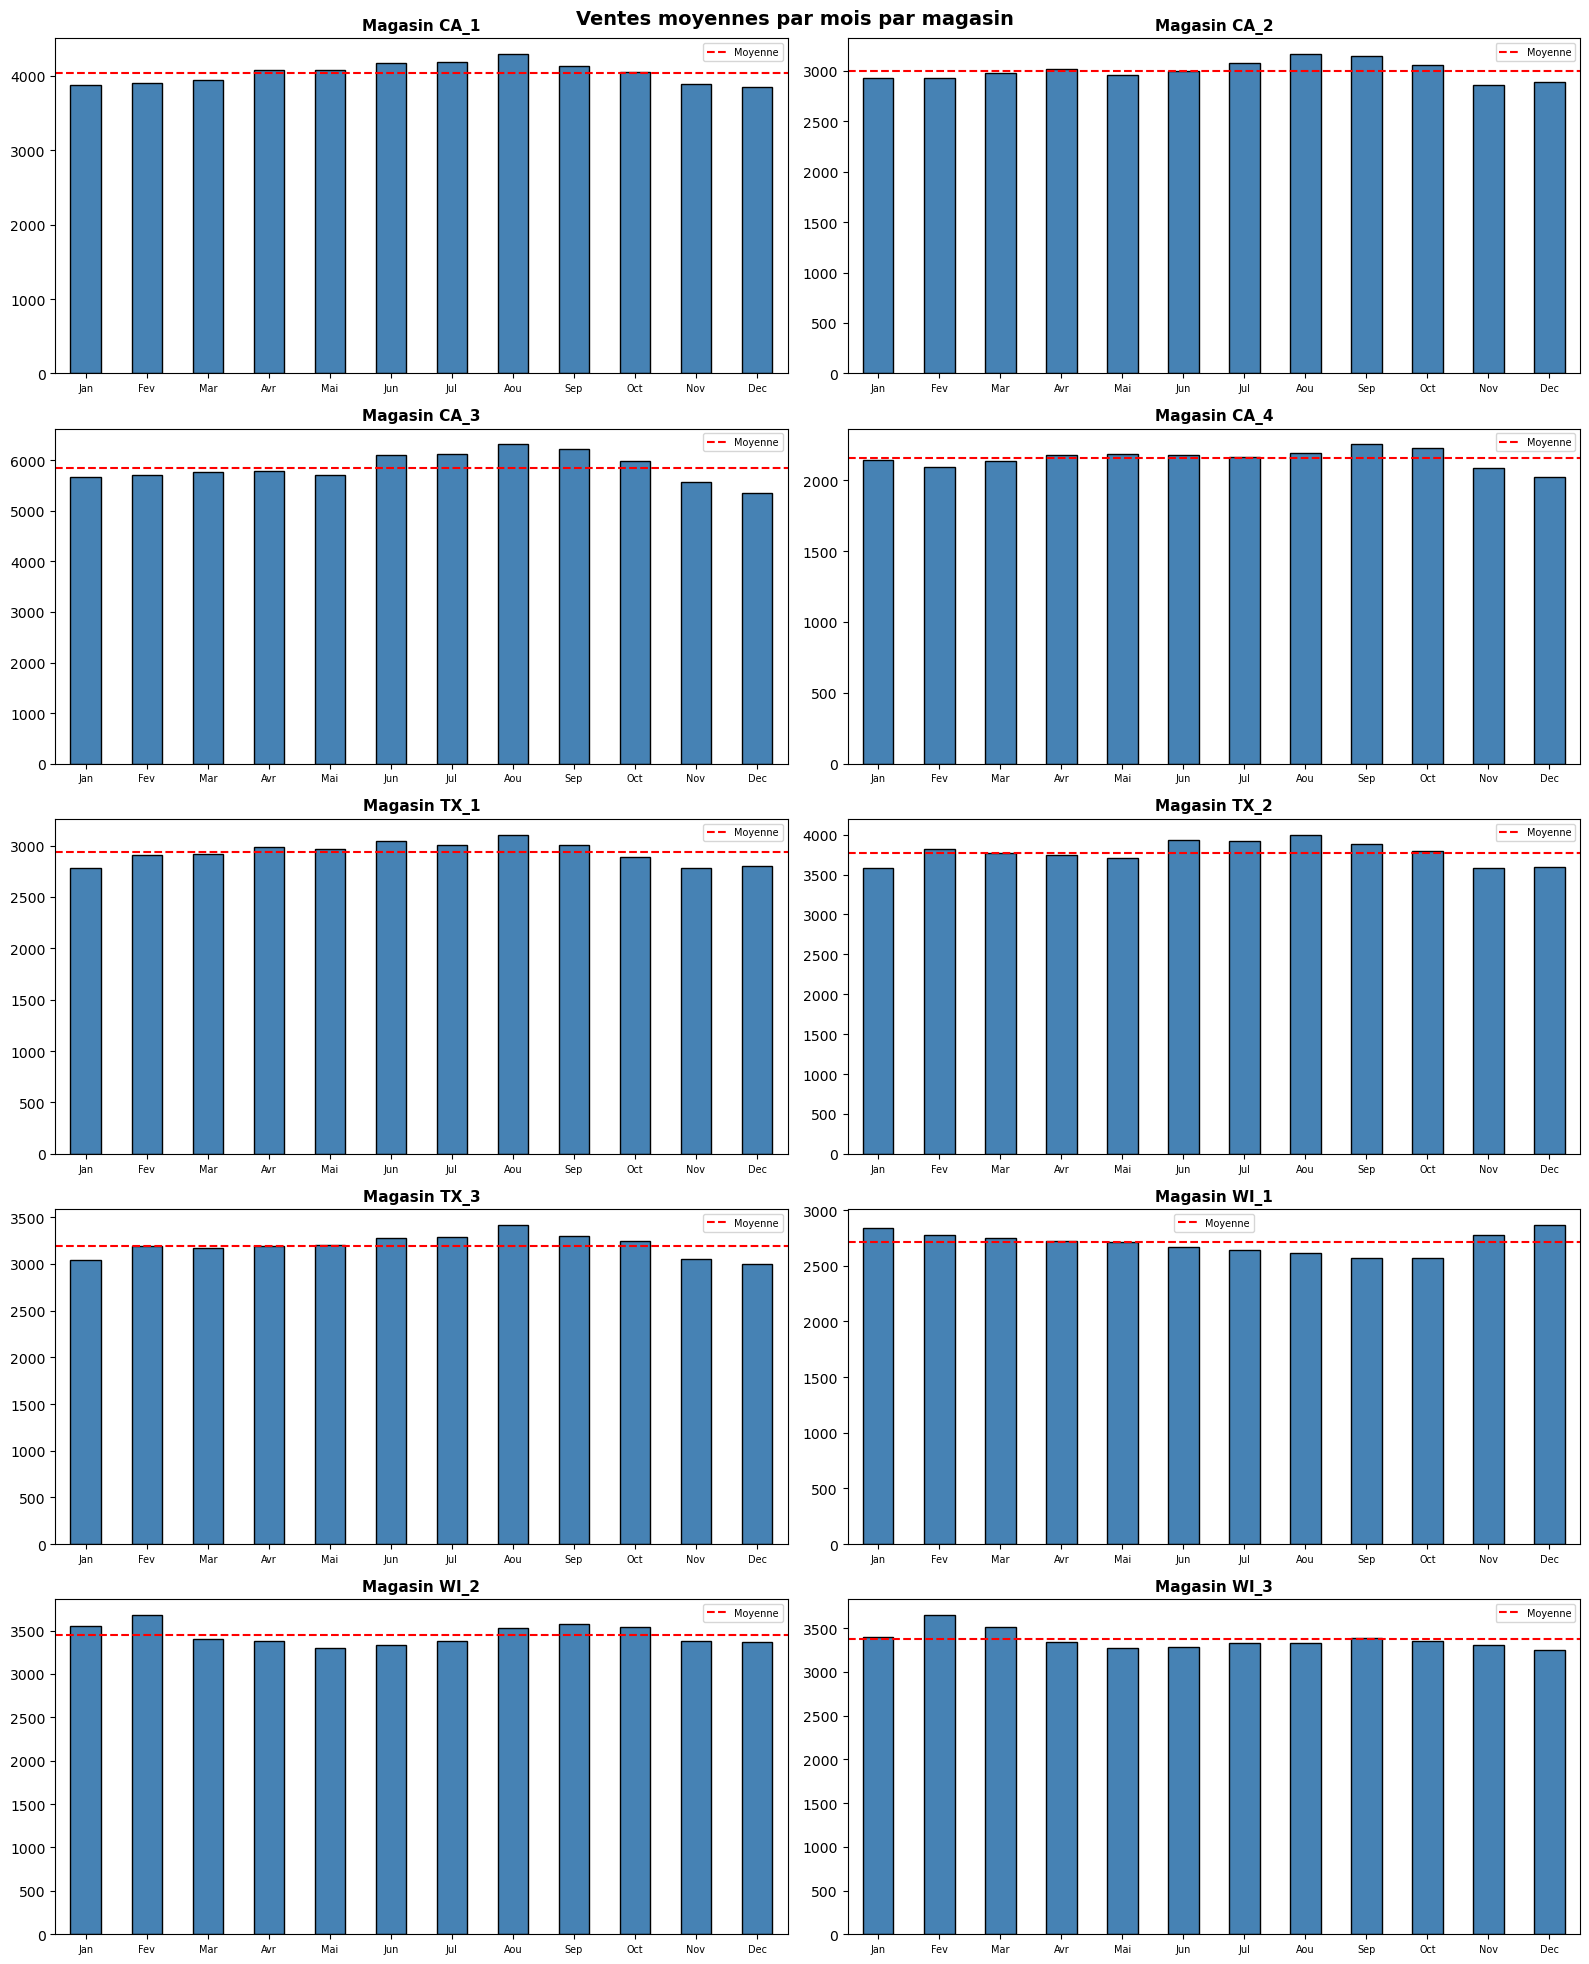

In [3]:
# Ventes moyennes par mois pour chaque magasin
sales_by_store = sales.groupby('store_id')[day_cols].sum()
mois_labels = ["Jan", "Fev", "Mar", "Avr", "Mai", "Jun",
               "Jul", "Aou", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, store in enumerate(sorted(sales_by_store.index)):
    store_daily = pd.Series(
        sales_by_store.loc[store].values,
        index=[day_to_date[d] for d in day_cols]
    ).sort_index()
    
    ventes_mois = store_daily.groupby(store_daily.index.month).mean()
    ventes_mois.index = mois_labels
    baseline_store = store_daily.mean()
    
    ventes_mois.plot(kind="bar", ax=axes[i], color="steelblue", edgecolor="black")
    axes[i].axhline(baseline_store, color="red", linestyle="--", label="Moyenne")
    axes[i].set_title(f'Magasin {store}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0, labelsize=7)
    axes[i].legend(fontsize=7)

plt.suptitle('Ventes moyennes par mois par magasin', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

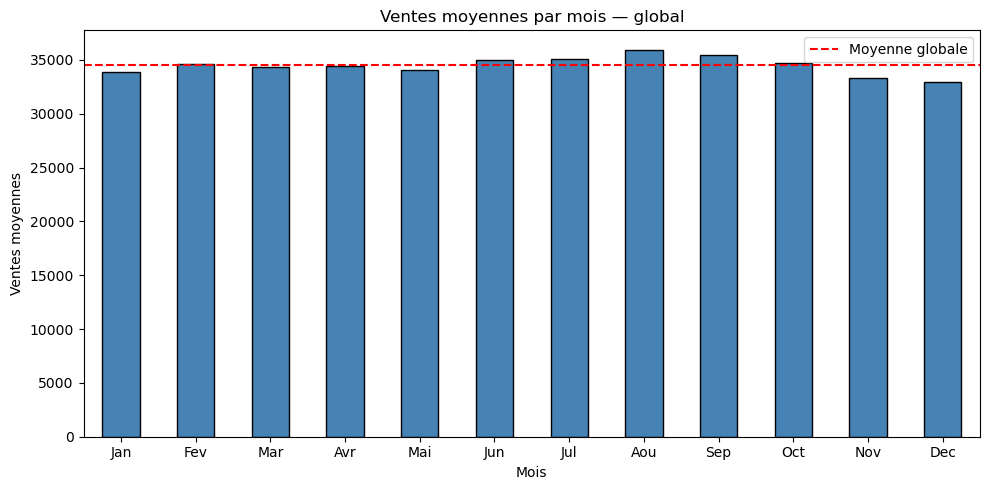

Mois le plus fort : Aou
Mois le plus faible : Dec


In [5]:
mois_labels = ["Jan", "Fev", "Mar", "Avr", "Mai", "Jun",
               "Jul", "Aou", "Sep", "Oct", "Nov", "Dec"]

total_daily = pd.Series(
    sales[day_cols].sum().values,
    index=[day_to_date[d] for d in day_cols]
).sort_index()

baseline = total_daily.mean()

ventes_par_mois = total_daily.groupby(total_daily.index.month).mean()
ventes_par_mois.index = mois_labels

ventes_par_mois.plot(kind="bar", color="steelblue", edgecolor="black", figsize=(10, 5))
plt.title("Ventes moyennes par mois — global")
plt.xlabel("Mois")
plt.ylabel("Ventes moyennes")
plt.axhline(baseline, color="red", linestyle="--", label="Moyenne globale")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

print("Mois le plus fort :", mois_labels[ventes_par_mois.argmax()])
print("Mois le plus faible :", mois_labels[ventes_par_mois.argmin()])

In [9]:
# Calcul de l'écart entre le mois le plus fort et le plus faible
max_mois = ventes_par_mois.max()
min_mois = ventes_par_mois.min()
ecart = (max_mois - min_mois) / min_mois * 100
print(f"Mois le plus fort ({ventes_par_mois.idxmax()}) : {max_mois:.0f} ventes/jour")
print(f"Mois le plus faible ({ventes_par_mois.idxmin()}) : {min_mois:.0f} ventes/jour")
print(f"Écart : {ecart:.1f}%")

Mois le plus fort (Aou) : 35947 ventes/jour
Mois le plus faible (Dec) : 32980 ventes/jour
Écart : 9.0%


Les ventes sont très stables d'un mois à l'autre, aussi bien au niveau global que par magasin. Toutes les barres restent proches de la moyenne globale avec des écarts minimes.

Le mois le plus fort est Août et le plus faible est Décembre avec un écart de 9%. Cette stabilité est observée de manière cohérente sur l'ensemble des 10 magasins sans exception.

On peut donc conclure que la saisonnalité mensuelle est faible, les mois seuls n'expliquent pas les variations de ventes.

## 2. Saisonnalité hebdomadaire des ventes

La saisonnalité mensuelle étant faible, on affine l'analyse en descendant à l'échelle de la semaine. On cherche à savoir si certains jours de la semaine génèrent structurellement plus de ventes que d'autres.

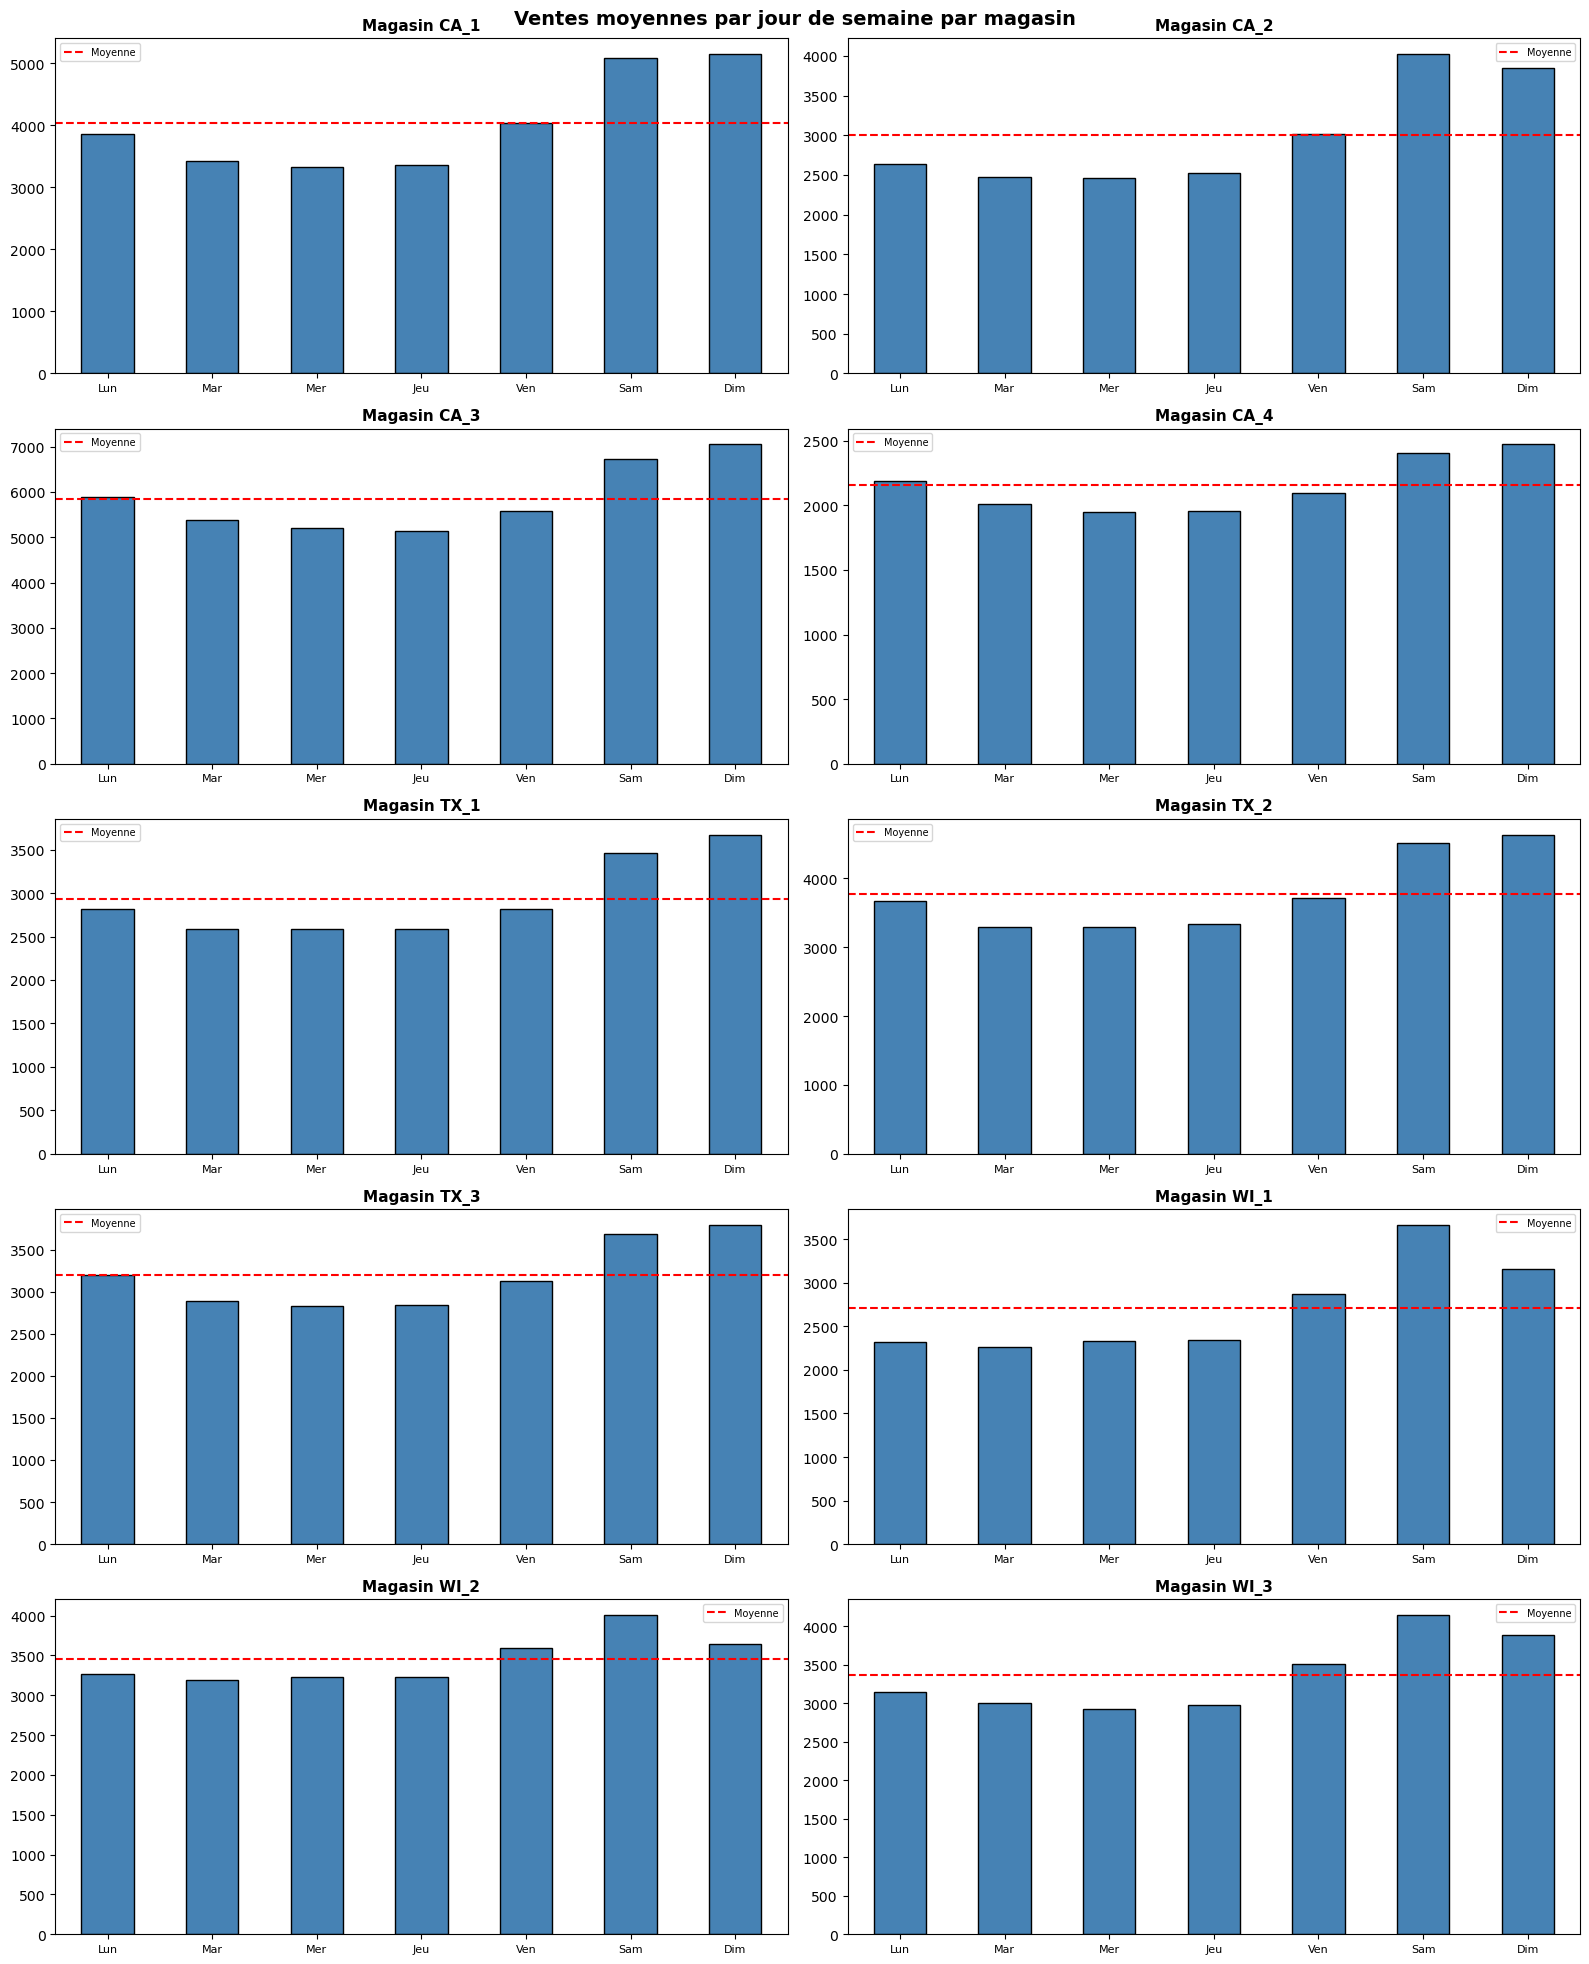

In [7]:
jours_labels = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
sales_by_store = sales.groupby('store_id')[day_cols].sum()

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, store in enumerate(sorted(sales_by_store.index)):
    store_daily = pd.Series(
        sales_by_store.loc[store].values,
        index=[day_to_date[d] for d in day_cols]
    ).sort_index()
    
    ventes_semaine = store_daily.groupby(store_daily.index.dayofweek).mean()
    ventes_semaine.index = jours_labels
    baseline_store = store_daily.mean()
    
    ventes_semaine.plot(kind="bar", ax=axes[i], color="steelblue", edgecolor="black")
    axes[i].axhline(baseline_store, color="red", linestyle="--", label="Moyenne")
    axes[i].set_title(f'Magasin {store}', fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=0, labelsize=8)
    axes[i].legend(fontsize=7)

plt.suptitle('Ventes moyennes par jour de semaine par magasin', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

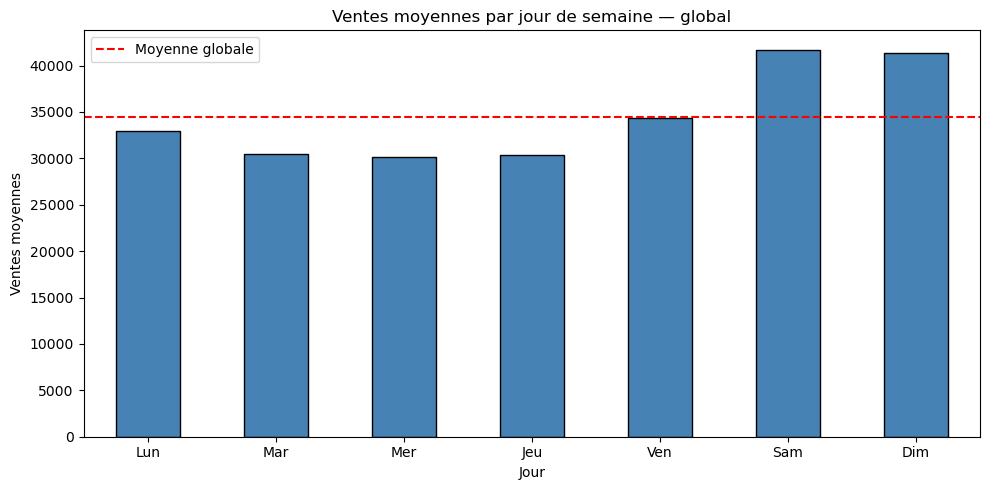

Jour le plus fort : Sam
Jour le plus faible : Mer


In [8]:
ventes_semaine_global = total_daily.groupby(total_daily.index.dayofweek).mean()
ventes_semaine_global.index = jours_labels

ventes_semaine_global.plot(kind="bar", color="steelblue", edgecolor="black", figsize=(10, 5))
plt.title("Ventes moyennes par jour de semaine — global")
plt.xlabel("Jour")
plt.ylabel("Ventes moyennes")
plt.axhline(baseline, color="red", linestyle="--", label="Moyenne globale")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

print("Jour le plus fort :", jours_labels[ventes_semaine_global.argmax()])
print("Jour le plus faible :", jours_labels[ventes_semaine_global.argmin()])

In [11]:
# Calcul de l'écart entre le jour de la semaine le plus fort et le plus faible
max_jour = ventes_semaine_global.max()
min_jour = ventes_semaine_global.min()
ecart = (max_jour - min_jour) / min_jour * 100
print(f"Jour le plus fort ({ventes_semaine_global.idxmax()}) : {max_jour:.0f} ventes/jour")
print(f"Jour le plus faible ({ventes_semaine_global.idxmin()}) : {min_jour:.0f} ventes/jour")
print(f"Écart : {ecart:.1f}%")

Jour le plus fort (Sam) : 41706 ventes/jour
Jour le plus faible (Mer) : 30130 ventes/jour
Écart : 38.4%


Contrairement à la saisonnalité mensuelle qui affichait un écart de 9%, la saisonnalité hebdomadaire est forte avec un écart de 38.4% entre le Samedi le jour le plus fort et le Mercredi le plus faible. Ce pattern est identique dans tous les états et tous les magasins sans exception.

Globalement le weekend génère significativement plus de ventes que la semaine. Cette saisonnalité hebdomadaire est une information structurelle importante, elle justifie l'utilisation du jour de semaine comme variable dans notre modèle de prévision, ainsi que l'utilisation de lag_7 pour capturer ce cycle hebdomadaire.

## 3. Analyse des événements du calendrier

La saisonnalité mensuelle est faible (9%) et la saisonnalité hebdomadaire est structurelle et prévisible (38.4%). Ces deux facteurs ne suffisent donc pas à expliquer les pics et creux anormaux observés dans les données.

On s'intéresse maintenant aux événements ponctuels du calendrier américain comme Thanksgiving, Christmas, SuperBowl, Easter etc. qui pourraient créer des variations exceptionnelles au-delà de la tendance normale.
Cependant, cette analyse en particulier témoigne d'une réflexion encore plus aboutie car certains événements comme Noël ou Thanksgiving nécessitent une fenêtre plus large car les gens anticipent leurs achats plusieurs semaines à l'avance.

Les autres événements ont un impact plus court et ponctuel, une fenêtre de J-7 à J+7 est suffisante.

In [12]:
# events où les gens anticipent longtemps à l'avance avec une fenêtre J-28 à J+7
events_longs = {
    "Christmas"   : list(range(-28, 8)),
    "Thanksgiving": list(range(-28, 8)),
    "Halloween"   : list(range(-28, 8)),
    "NewYear"     : list(range(-28, 8)),
    "Chanukah End": list(range(-28, 8))
}

# tous les autres events avec une fenêtre J-7 à J+7
events_courts = {
    "SuperBowl"        : list(range(-7, 8)),
    "ValentinesDay"    : list(range(-7, 8)),
    "PresidentsDay"    : list(range(-7, 8)),
    "LentStart"        : list(range(-7, 8)),
    "StPatricksDay"    : list(range(-7, 8)),
    "OrthodoxEaster"   : list(range(-7, 8)),
    "Cinco De Mayo"    : list(range(-7, 8)),
    "Mother's day"     : list(range(-7, 8)),
    "MemorialDay"      : list(range(-7, 8)),
    "NBAFinalsStart"   : list(range(-7, 8)),
    "NBAFinalsEnd"     : list(range(-7, 8)),
    "Father's day"     : list(range(-7, 8)),
    "IndependenceDay"  : list(range(-7, 8)),
    "LaborDay"         : list(range(-7, 8)),
    "ColumbusDay"      : list(range(-7, 8)),
    "VeteransDay"      : list(range(-7, 8)),
    "EidAlAdha"        : list(range(-7, 8)),
    "Eid al-Fitr"      : list(range(-7, 8)),
    "Ramadan starts"   : list(range(-7, 8)),
    "MartinLutherKingDay": list(range(-7, 8)),
    "Easter"           : list(range(-7, 8)),
    "OrthodoxChristmas": list(range(-7, 8)),
    "Purim End"        : list(range(-7, 8)),
    "Pesach End"       : list(range(-7, 8)),
    "LentWeek2"        : list(range(-7, 8))
}

# on fusionne les deux dictionnaires
tous_les_events = {**events_courts, **events_longs}

print(f"Nombre total d events à analyser : {len(tous_les_events)}")
print("Events avec fenêtre longue (J-28) :", list(events_longs.keys()))
print("Events avec fenêtre courte (J-7)  :", list(events_courts.keys()))

Nombre total d events à analyser : 30
Events avec fenêtre longue (J-28) : ['Christmas', 'Thanksgiving', 'Halloween', 'NewYear', 'Chanukah End']
Events avec fenêtre courte (J-7)  : ['SuperBowl', 'ValentinesDay', 'PresidentsDay', 'LentStart', 'StPatricksDay', 'OrthodoxEaster', 'Cinco De Mayo', "Mother's day", 'MemorialDay', 'NBAFinalsStart', 'NBAFinalsEnd', "Father's day", 'IndependenceDay', 'LaborDay', 'ColumbusDay', 'VeteransDay', 'EidAlAdha', 'Eid al-Fitr', 'Ramadan starts', 'MartinLutherKingDay', 'Easter', 'OrthodoxChristmas', 'Purim End', 'Pesach End', 'LentWeek2']


## 3. Analyse des événements du calendrier

### 3.1 Méthodologie

Pour chaque événement on calcule la variation des ventes par rapport à la baseline globale sur une fenêtre temporelle adaptée :

- **Fenêtre longue (J-28 à J+7)** pour les events anticipés longtemps à l'avance : Christmas, Thanksgiving, Halloween, NewYear, Chanukah End
- **Fenêtre courte (J-7 à J+7)** pour tous les autres events ponctuels

Le nombre d'occurrences indique sur combien d'années l'événement a été observé. Plus ce nombre est élevé, plus le résultat est fiable car calculé sur plusieurs années — c'est donc un pattern reproductible et prévisible.

### 3.2 Définition de la fonction de calcul d'impact

Pour analyser 30 événements sans répéter le même code 30 fois, on définit une fonction `impact_event` qui retourne la variation des ventes en pourcentage par rapport à la baseline pour chaque jour de la fenêtre.

In [13]:
def impact_event(nom_event, offsets):
    
    # on récupère les dates de l event
    dates = calendar[calendar["event_name_1"] == nom_event]["date"].tolist()
    print(f"{nom_event} : {len(dates)} occurrences")
    
    # pour chaque offset on calcule la variation, l'offset me dit à quel jour correspond chaque variation.
    variations = []
    for offset in offsets:
        ventes = []
        for date in dates:
            date_cible = date + pd.Timedelta(days=offset)
            if date_cible in total_daily.index:
                ventes.append(total_daily[date_cible])
        if ventes:
            variations.append((np.mean(ventes) / baseline - 1) * 100)
        else:
            variations.append(0)
    
    return variations

### 3.3 Calcul de l'impact pour tous les événements

On applique la fonction à l'ensemble des événements et on stocke les résultats.

In [14]:
resultats_globaux = {}
for event, offsets in tous_les_events.items():
    variations = impact_event(event, offsets)
    resultats_globaux[event] = {
        "variations" : variations,
        "offsets"    : offsets
    }

SuperBowl : 6 occurrences
ValentinesDay : 6 occurrences
PresidentsDay : 6 occurrences
LentStart : 6 occurrences
StPatricksDay : 6 occurrences
OrthodoxEaster : 5 occurrences
Cinco De Mayo : 5 occurrences
Mother's day : 6 occurrences
MemorialDay : 6 occurrences
NBAFinalsStart : 6 occurrences
NBAFinalsEnd : 6 occurrences
Father's day : 4 occurrences
IndependenceDay : 5 occurrences
LaborDay : 5 occurrences
ColumbusDay : 5 occurrences
VeteransDay : 5 occurrences
EidAlAdha : 5 occurrences
Eid al-Fitr : 5 occurrences
Ramadan starts : 6 occurrences
MartinLutherKingDay : 5 occurrences
Easter : 5 occurrences
OrthodoxChristmas : 5 occurrences
Purim End : 6 occurrences
Pesach End : 6 occurrences
LentWeek2 : 6 occurrences
Christmas : 5 occurrences
Thanksgiving : 5 occurrences
Halloween : 5 occurrences
NewYear : 5 occurrences
Chanukah End : 5 occurrences


### 3.4 Visualisation de l'impact par événement

Pour chaque événement on visualise la variation des ventes jour par jour autour de la date J. Les barres rouges indiquent une hausse des ventes, les bleues une baisse.

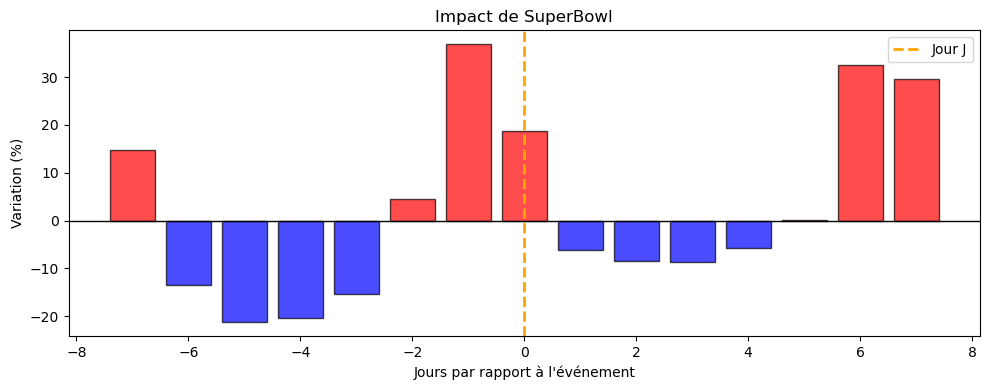

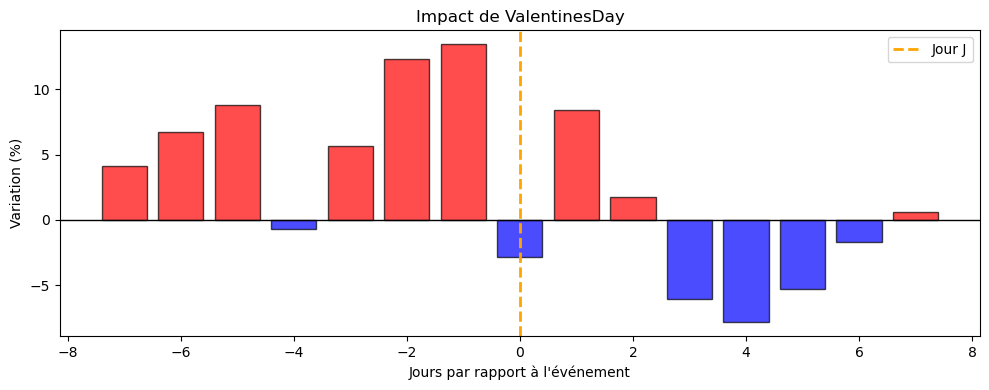

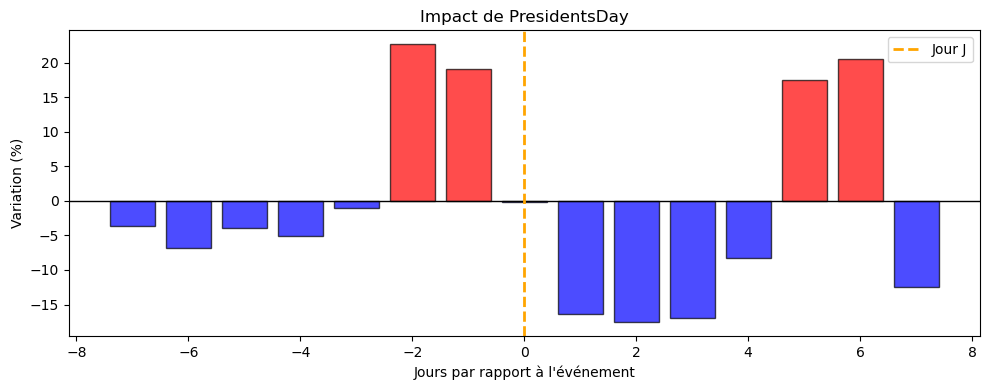

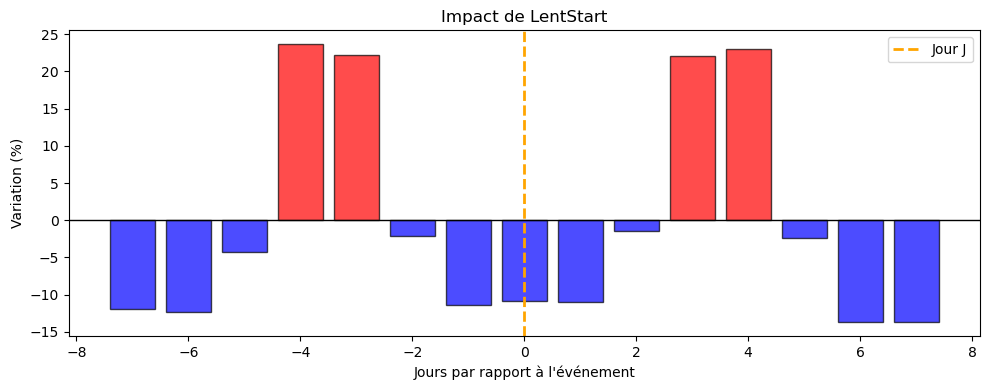

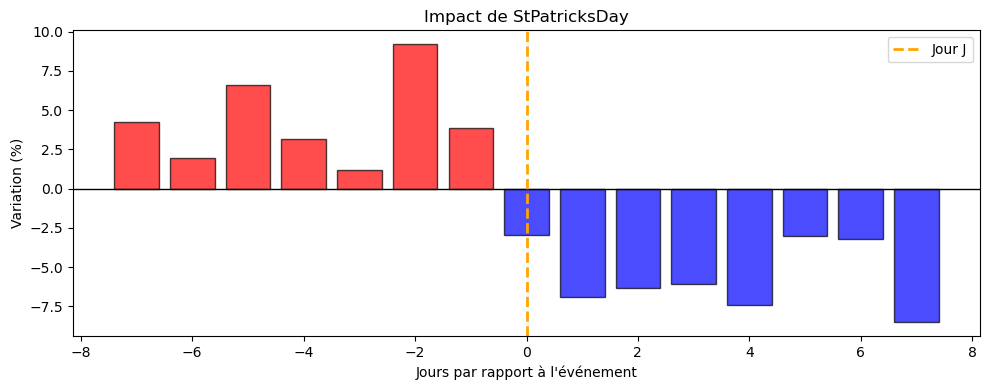

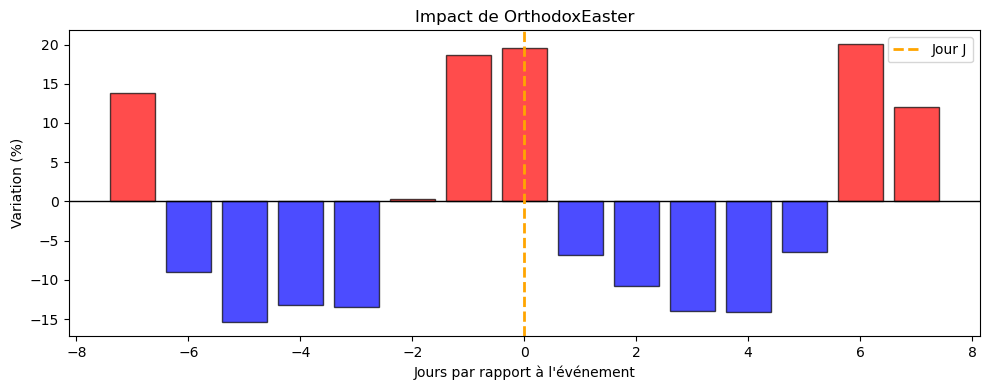

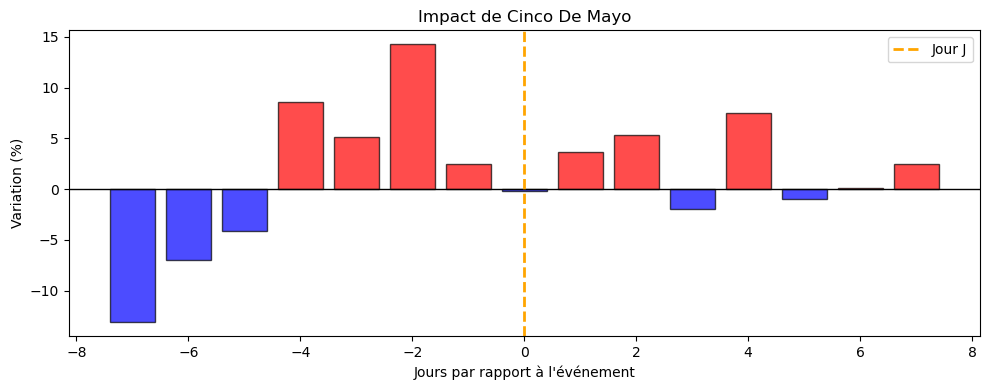

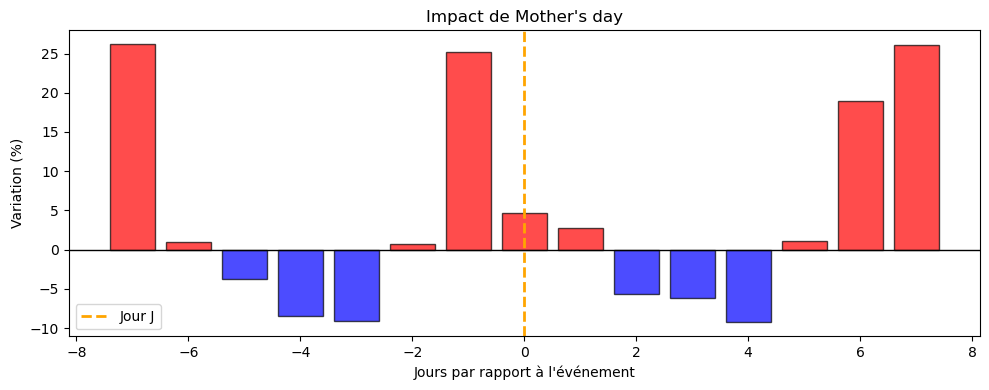

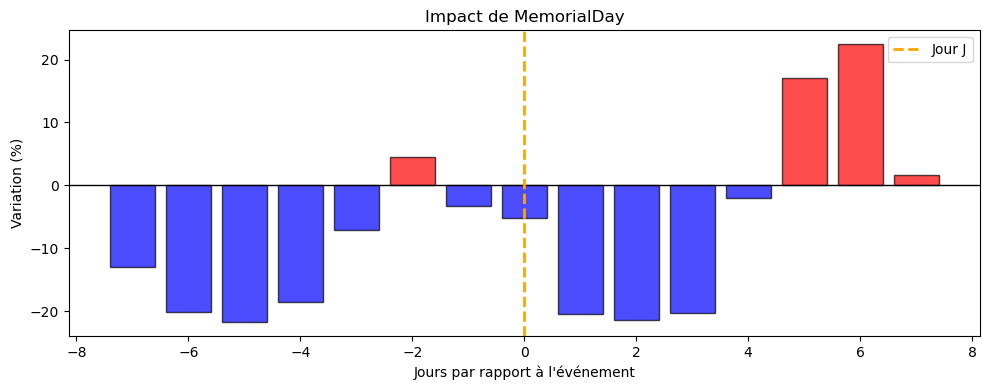

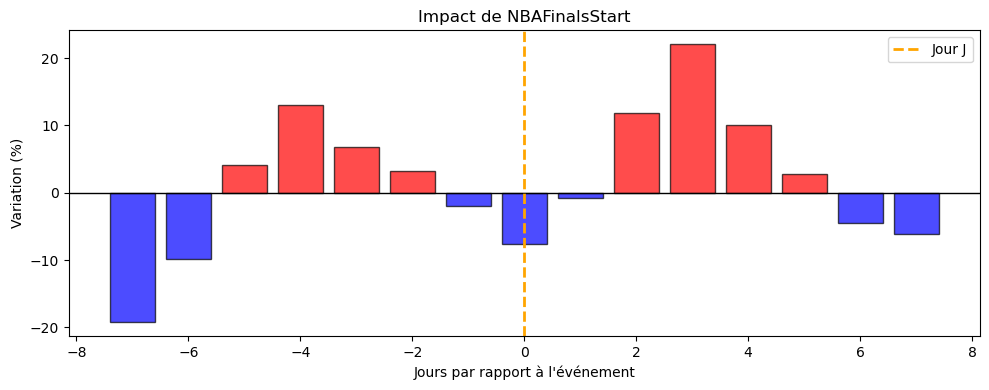

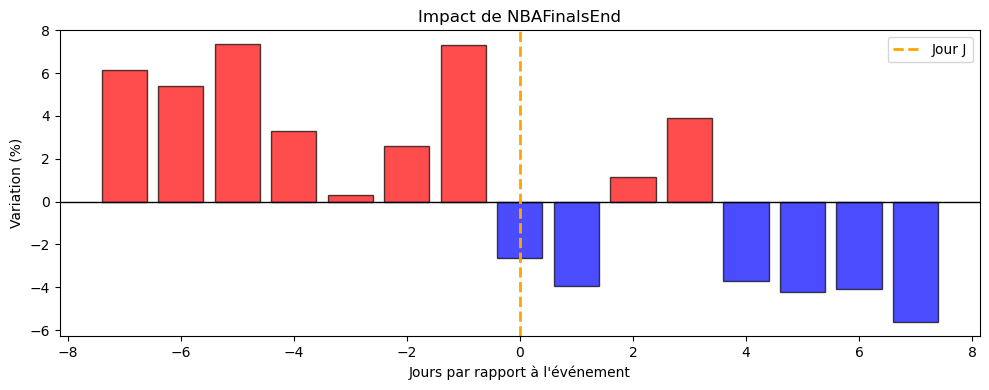

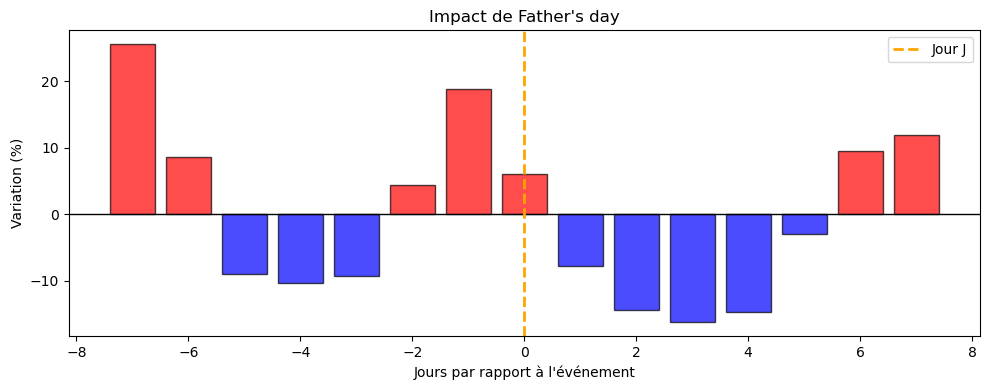

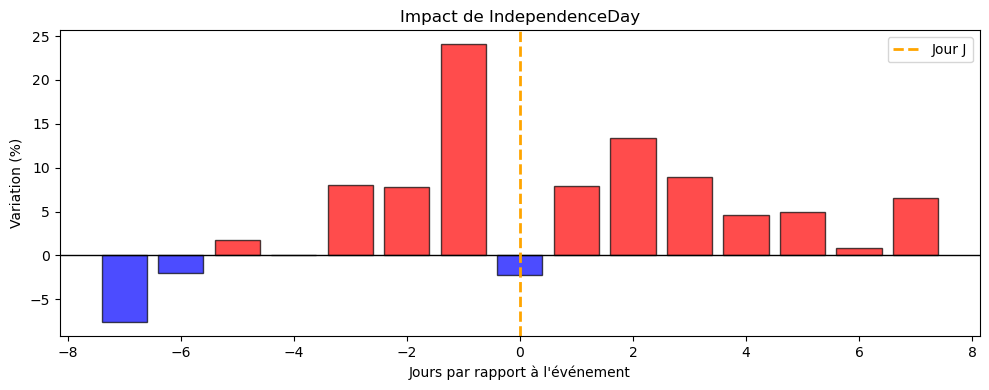

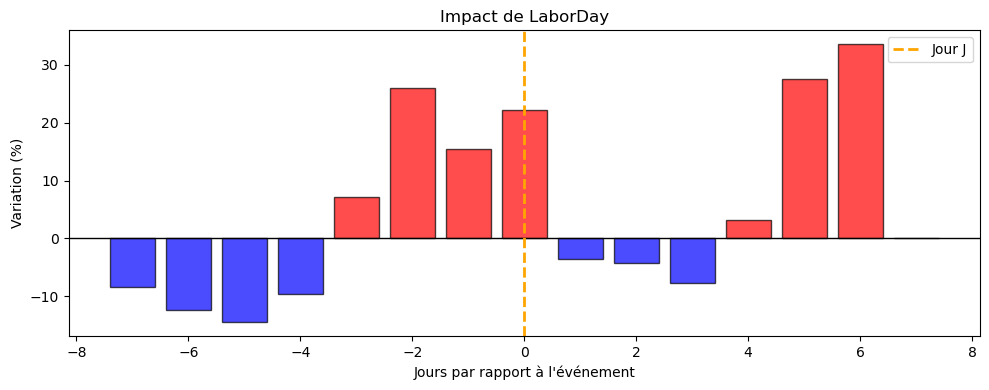

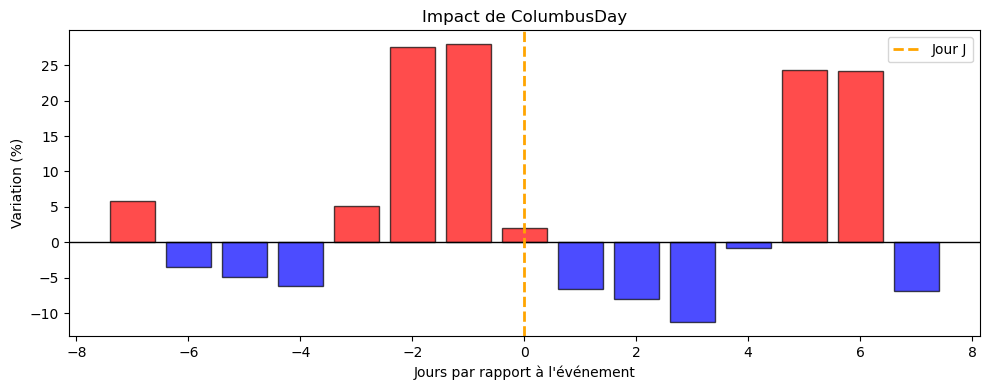

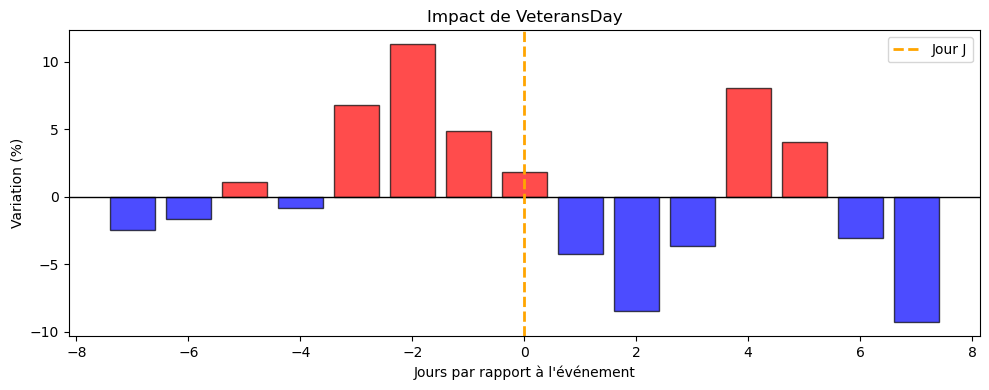

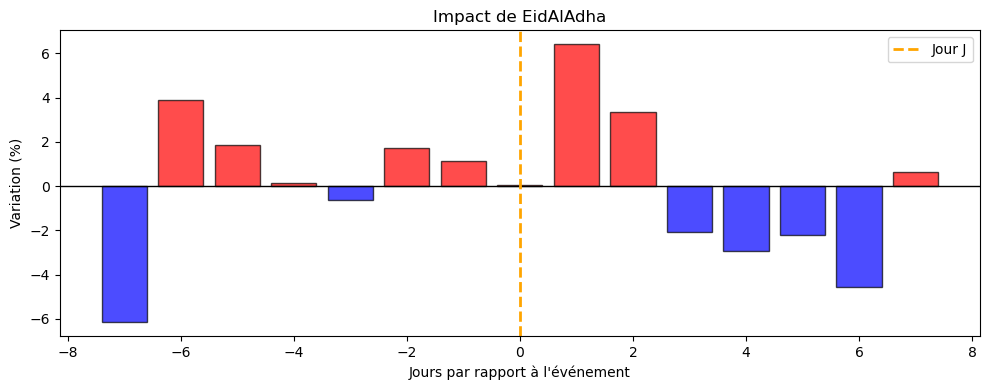

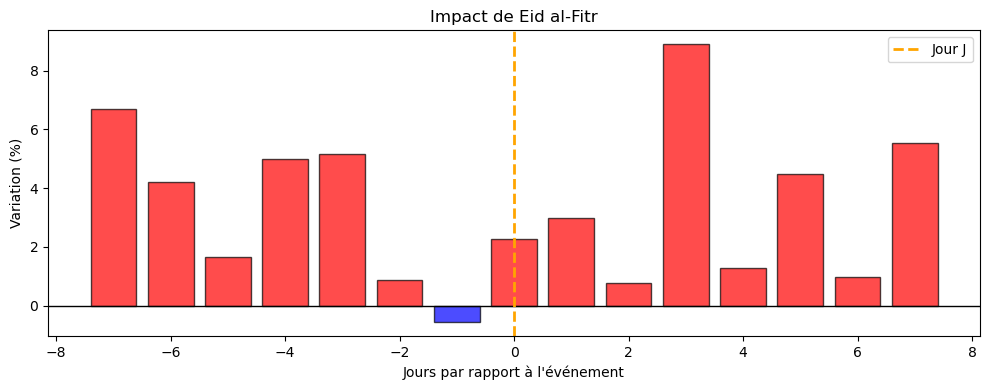

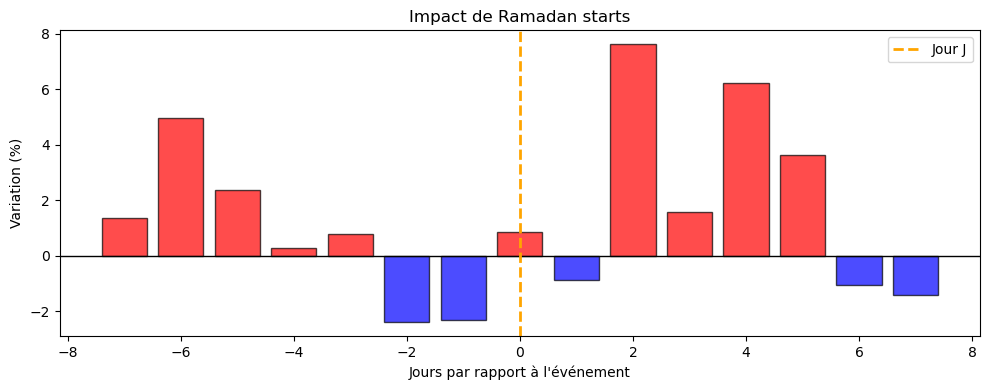

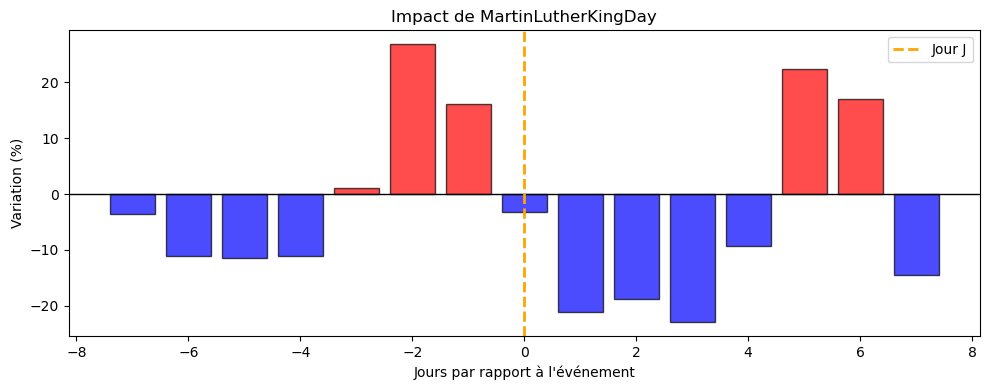

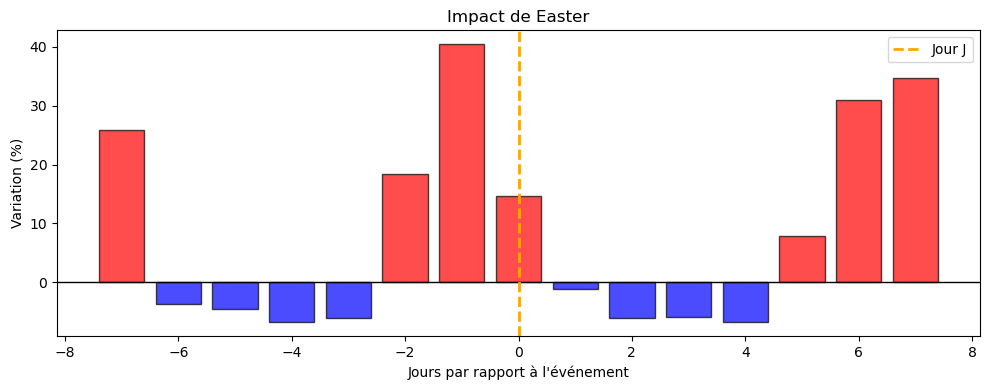

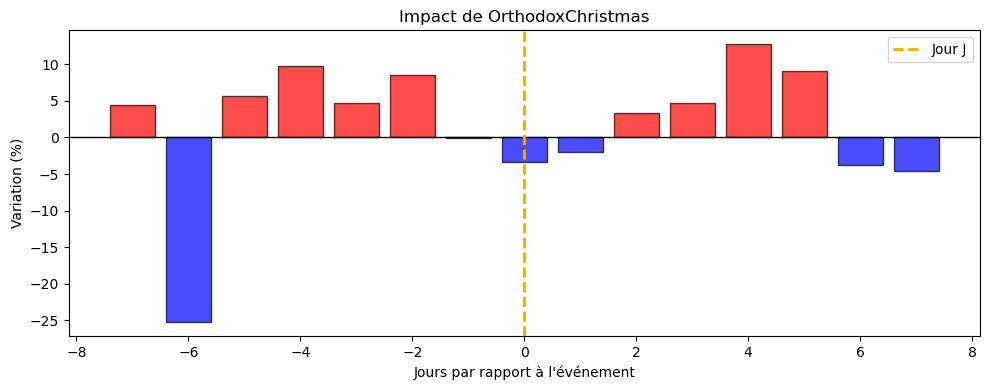

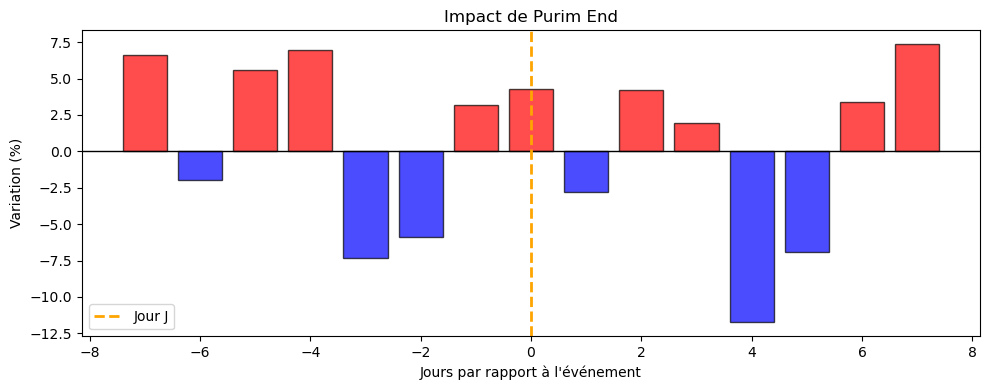

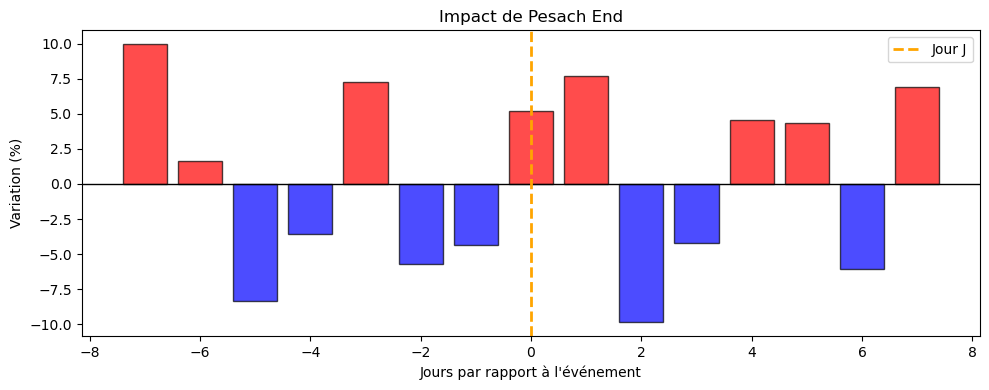

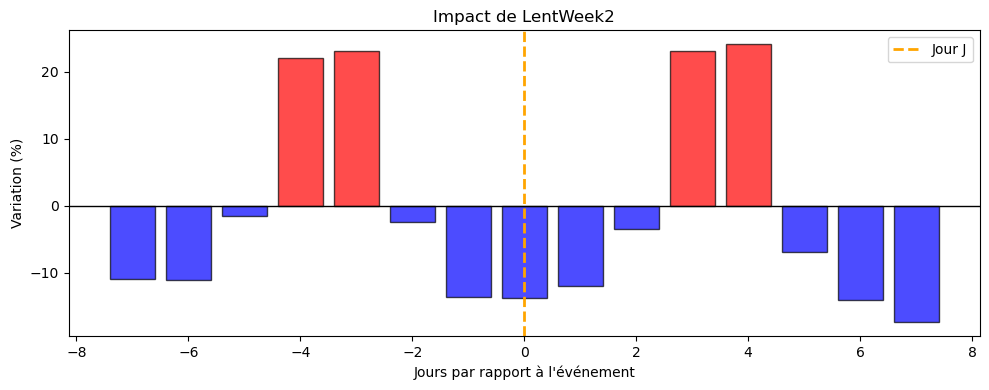

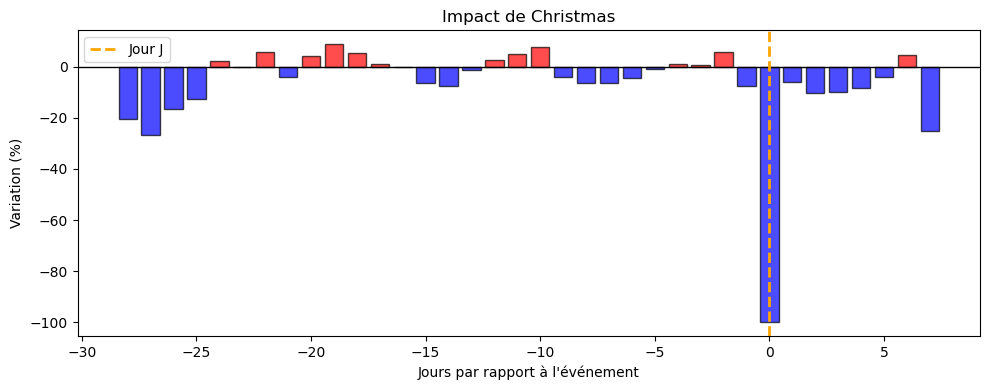

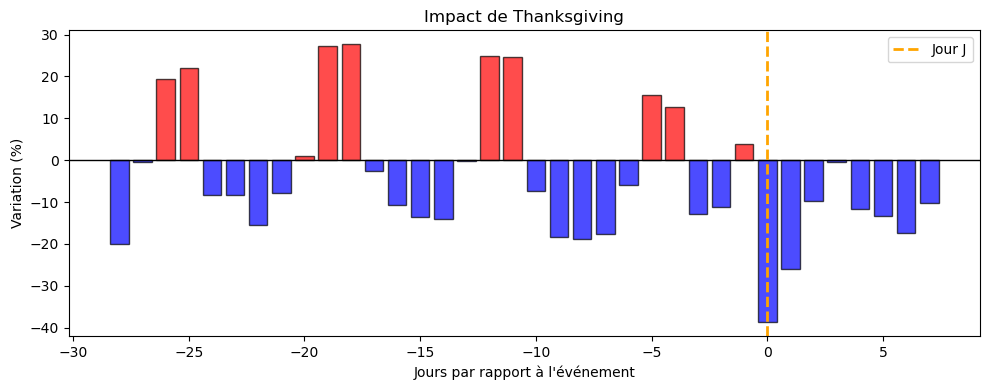

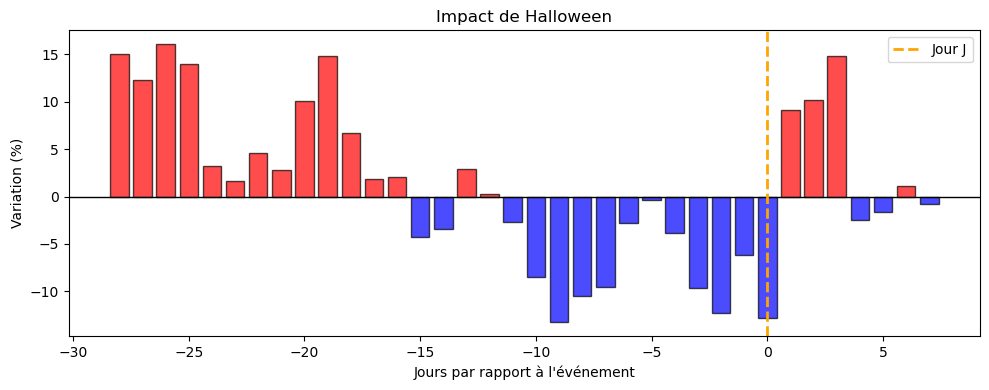

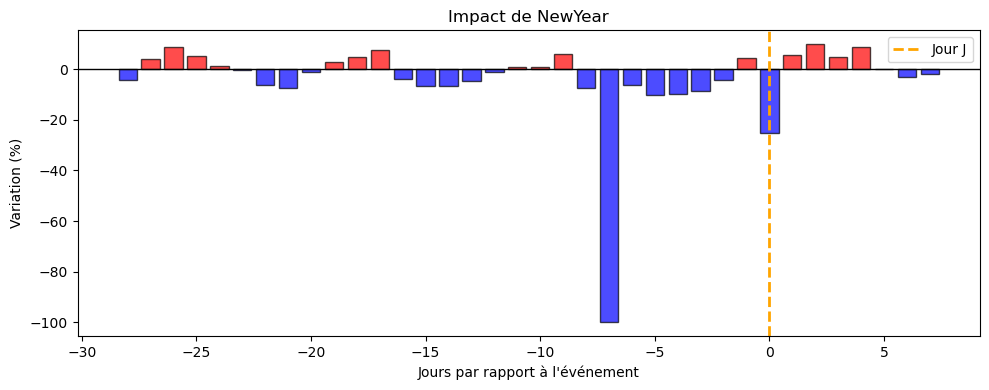

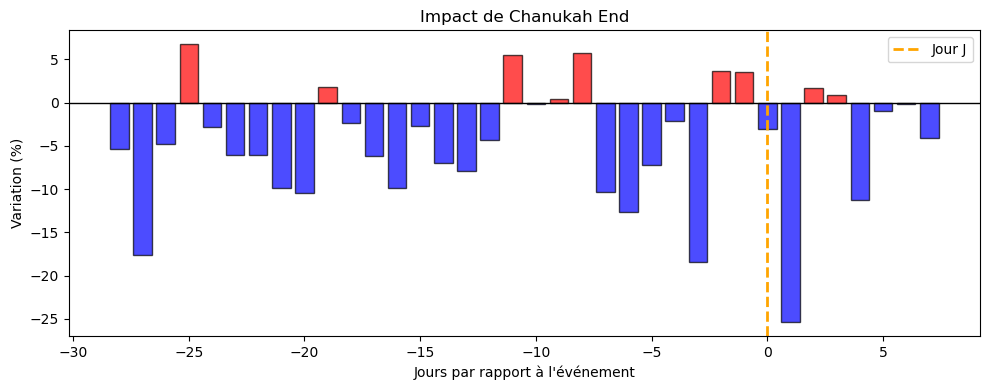

In [15]:
for event, data in resultats_globaux.items():
    offsets    = data["offsets"]
    variations = data["variations"]
    couleurs   = ["red" if v > 0 else "blue" for v in variations]
    
    plt.figure(figsize=(10, 4))
    plt.bar(offsets, variations, color=couleurs, edgecolor="black", alpha=0.7)
    plt.axhline(0, color="black", linewidth=1)
    plt.axvline(0, color="orange", linewidth=2, linestyle="--", label="Jour J")
    plt.title(f"Impact de {event}")
    plt.xlabel("Jours par rapport à l'événement")
    plt.ylabel("Variation (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()

### 3.5 Interprétation des résultats

**Events à fort impact**

Easter est l'event avec le pic le plus fort: +40% à J-1 ce qui s'explique par les courses du samedi avant Pâques. SuperBowl suit avec +35% à J-1, les gens achetant nourriture et boissons pour la soirée. LaborDay génère une hausse étalée de +33% de J-2 à J+6 car c'est un long weekend avec des achats progressifs.

Thanksgiving est particulier car on observe des pics par vagues à J-20, J-10 et J-5, mais une chute de -40% le jour J lui-même car les magasins ferment tôt. Halloween est l'event le plus anticipé du dataset avec des pics entre J-28 et J-25, les gens achètent leurs décorations et bonbons un mois à l'avance. Christmas affiche -100% le jour J car Walmart est fermé le 25 décembre.

**Events à impact moyen**

Les jours fériés qui créent un long weekend (PresidentsDay, MartinLutherKingDay, ColumbusDay) génèrent des hausses entre +22% et +27% à J-2. Mother's Day et Father's Day montrent le même pattern avec +25% à J-7, les gens anticipent une semaine avant. IndependenceDay génère +24% à J-1 lié aux barbecues du 4 juillet.

**Events à faible impact**

Les fêtes religieuses comme Eid al-Adha, Eid al-Fitr et Ramadan ont moins de 10% de variation, elles concernent une partie minoritaire de la clientèle Walmart. OrthodoxChristmas et les fêtes juives ont un impact négligeable. NewYear semble montrer une chute mais elle est en réalité due à Christmas qui est dans sa fenêtre d'analyse.

## 4. Impact des événements par magasin

L'analyse globale nous a permis d'identifier les événements les plus impactants. On descend maintenant à l'échelle du magasin pour vérifier si tous les magasins réagissent de la même façon ou si certains sont plus sensibles que d'autres. Ces résultats alimenteront directement notre partie Recherche Opérationnelle.

### 4.1 Fonction de calcul de l'impact par magasin

On réutilise la même logique que pour l'analyse globale mais cette fois on compare chaque magasin à sa propre moyenne et non à la baseline globale.

In [17]:
daily_by_store = {}
for store in sales["store_id"].unique():
    ventes_store = sales[sales["store_id"] == store][day_cols].sum()
    daily_by_store[store] = pd.Series(
        ventes_store.values,
        index=[day_to_date[d] for d in day_cols]
    ).sort_index()

def impact_event_magasin(store, nom_event, offsets):
    serie    = daily_by_store[store]
    baseline = serie.mean()
    dates    = calendar[calendar["event_name_1"] == nom_event]["date"].tolist()
    
    variations = []
    for offset in offsets:
        ventes = []
        for date in dates:
            date_cible = date + pd.Timedelta(days=offset)
            if date_cible in serie.index:
                ventes.append(serie[date_cible])
        if ventes:
            variations.append((np.mean(ventes) / baseline - 1) * 100)
        else:
            variations.append(0)
    return variations

### 4.2 Heatmap impact des 5 events clés par magasin

Pour chaque magasin et chaque event on calcule le pic d'impact maximum. Le vert indique une hausse des ventes, le rouge une baisse.

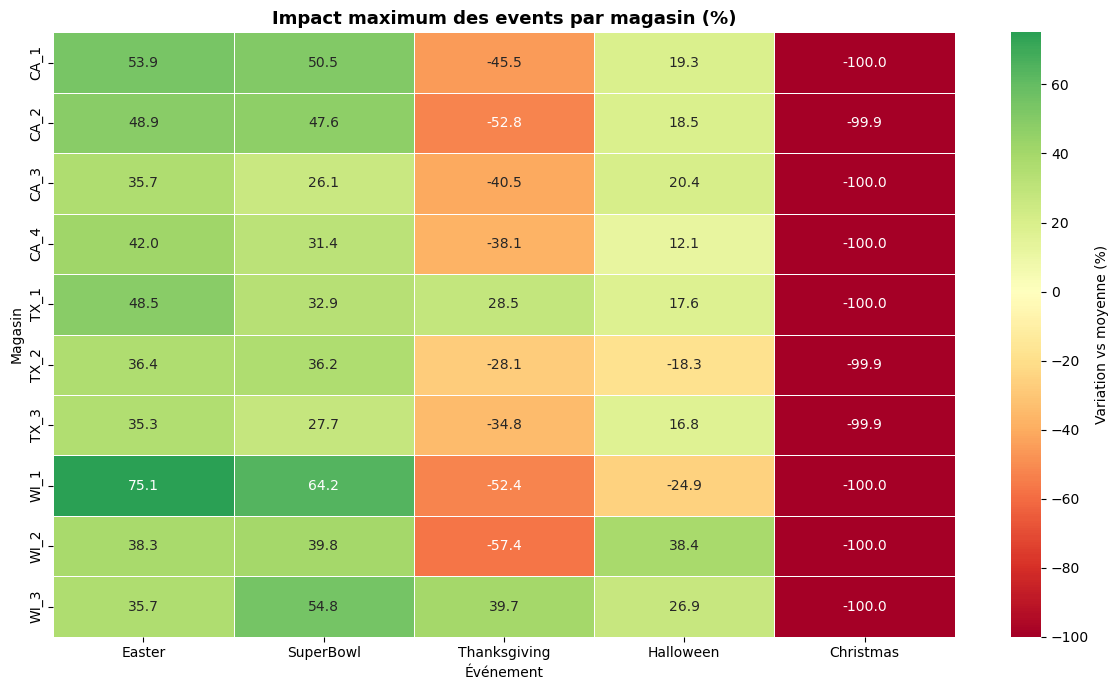

In [19]:
events_cles  = ["Easter", "SuperBowl", "Thanksgiving", "Halloween", "Christmas"]
offsets_cles = {
    "Easter"      : list(range(-7, 8)),
    "SuperBowl"   : list(range(-7, 8)),
    "Thanksgiving": list(range(-28, 8)),
    "Halloween"   : list(range(-28, 8)),
    "Christmas"   : list(range(-28, 8))
}

heatmap_data = pd.DataFrame(
    index=sorted(daily_by_store.keys()),
    columns=events_cles
)

for store in sorted(daily_by_store.keys()):
    for event in events_cles:
        offsets    = offsets_cles[event]
        variations = impact_event_magasin(store, event, offsets)
        idx_max    = np.argmax(np.abs(variations))
        heatmap_data.loc[store, event] = round(variations[idx_max], 1)

heatmap_data = heatmap_data.astype(float)

plt.figure(figsize=(12, 7))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="RdYlGn",
            center=0, linewidths=0.5,
            cbar_kws={"label": "Variation vs moyenne (%)"})
plt.title("Impact maximum des events par magasin (%)", fontsize=13, fontweight='bold')
plt.xlabel("Événement")
plt.ylabel("Magasin")
plt.tight_layout()
plt.show()

### On interprète la heatmap

**Christmas (-100% pour tous les magasins)**
- Walmart est fermé le 25 décembre dans tous les états
- C'est le seul event qui impacte tous les magasins de façon identique
- Action : ne pas sur-stocker, anticiper la fermeture

**Easter (fort impact positif)**
- WI_1 est le magasin le plus sensible (+75%) 
- CA_1 et TX_1 suivent (+54%, +49%)
- CA_3 qui est pourtant le plus gros magasin réagit moins (+36%)
- Action : maximiser les stocks la veille dans tous les magasins, 
  en priorité WI_1 et CA_1

**SuperBowl (fort impact positif)**
- WI_1 encore le plus réactif (+64%)
- WI_3 très fort aussi (+55%)
- CA_3 le moins réactif (+26%)
- Action : stocker max la veille, surtout dans les magasins du Wisconsin

**Thanksgiving (comportements très différents selon les magasins)**
- WI_2 chute fortement (-57%)==>fermeture anticipée
- WI_1 chute aussi (-52%)
- WI_3 et TX_1 sont positifs (+40%, +29%)==> ces magasins profitent du weekend
- C'est l'event avec les comportements les plus hétérogènes
- Action : adapter la stratégie magasin par magasin

**Halloween (impact modéré)**
- WI_2 surperforme le plus (+38%)
- WI_3 aussi (+27%)
- TX_2 et WI_1 sont négatifs (-18%, -25%)==>ces magasins ne profitent pas d'Halloween
- Action : stocker tôt pour WI_2 et WI_3, pas de changement pour TX_2

**Conclusion générale**
- WI_1 est paradoxalement le magasin le plus sensible aux events 
  malgré ses faibles ventes globales
- CA_3 qui vend le plus est le moins réactif aux events
- Cela confirme qu'il faut analyser chaque magasin séparément 
  et ne pas appliquer une stratégie uniforme
- Ces résultats vont directement alimenter notre modèle de prévision 
  car la feature has_event aura un impact différent selon le magasin

cependant, le dataset s'arrête en mai donc notre prédiction sera à cette période. De ce fait, pour des raisons de précision pour notre modélisation, choisir des events comme Noël, Thanksgiving, etc aurait été plus intéressant car fort impact. Mais nous allons plus afiiner notre recherche sur des events en mai-juin max. Néanmoins cela ne change en rien en la cohérence de l'analyse ici et les conseils d'actions à effectuer écrites ci-dessus en conseil à Sophie Martin

In [20]:
# Events qui tombent en mai et juin
events_mai_juin = calendar[
    (calendar['date'].dt.month.isin([5, 6])) & 
    (calendar['event_name_1'].notna())
][['date', 'event_name_1']].drop_duplicates('event_name_1')

print(events_mai_juin.to_string())

           date    event_name_1
96   2011-05-05   Cinco De Mayo
99   2011-05-08    Mother's day
121  2011-05-30     MemorialDay
122  2011-05-31  NBAFinalsStart
134  2011-06-12    NBAFinalsEnd
141  2011-06-19    Father's day
827  2013-05-05  OrthodoxEaster
1247 2014-06-29  Ramadan starts


### 4.3 Heatmap events majeurs vs events de mai/juin

On sépare les deux analyses pour plus de lisibilité : les 5 events majeurs d'abord, puis les events spécifiques à mai/juin qui sont pertinents pour notre prévision future.

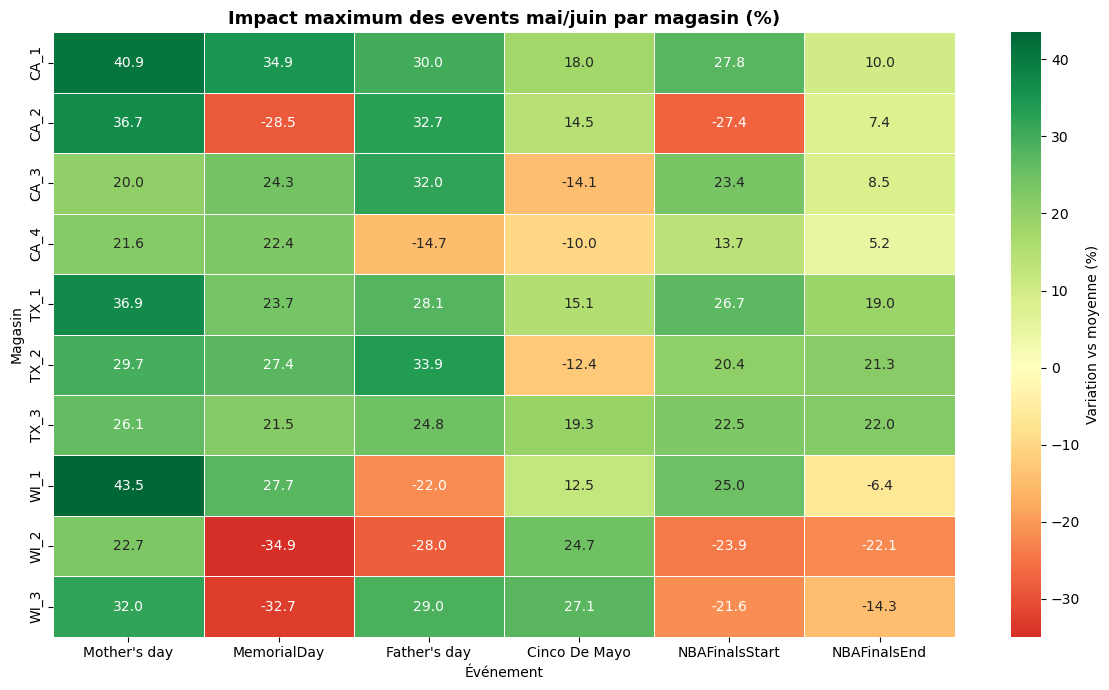

In [21]:
events_mai_juin  = ["Mother's day", "MemorialDay", "Father's day", 
                    "Cinco De Mayo", "NBAFinalsStart", "NBAFinalsEnd"]
offsets_mai_juin = {e: list(range(-7, 8)) for e in events_mai_juin}

heatmap_mai_juin = pd.DataFrame(index=sorted(daily_by_store.keys()), columns=events_mai_juin)

for store in sorted(daily_by_store.keys()):
    for event in events_mai_juin:
        variations = impact_event_magasin(store, event, offsets_mai_juin[event])
        idx_max    = np.argmax(np.abs(variations))
        heatmap_mai_juin.loc[store, event] = round(variations[idx_max], 1)

heatmap_mai_juin = heatmap_mai_juin.astype(float)

plt.figure(figsize=(12, 7))
sns.heatmap(heatmap_mai_juin, annot=True, fmt=".1f", cmap="RdYlGn",
            center=0, linewidths=0.5,
            cbar_kws={"label": "Variation vs moyenne (%)"})
plt.title("Impact maximum des events mai/juin par magasin (%)", fontsize=13, fontweight='bold')
plt.xlabel("Événement")
plt.ylabel("Magasin")
plt.tight_layout()
plt.show()

**Interprétation heatmap mai/juin :**

Mother's Day est l'event le plus impactant de cette période avec des hausses positives sur tous les magasins, WI_1 est le plus réactif avec +43.5% tandis que CA_3 reste le moins sensible avec +20%.

Memorial Day est l'event le plus hétérogène: certains magasins comme CA_1 affichent +34.9% tandis que WI_2 et WI_3 chutent à -34.9% et -32.7%. Cette opposition entre états suggère des habitudes de consommation très différentes selon les régions pour ce weekend prolongé.

Father's Day suit un pattern similaire à Mother's Day avec des hausses générales, mais WI_2 fait exception avec -28%.

Cinco De Mayo a un impact légèrement plus fort au Texas ce qui est cohérent avec la proximité géographique et culturelle avec le Mexique.

NBAFinalsEnd a un impact globalement faible, c'est cohérent avec notre classement des events à faible impact.

### conclusion générale 

De ce fait pour la modélisation finale avec streamlit on gardera mother's day, father's day et memorial day mais pour la recherche opérationnelle on parlera tout de même de Noël, Thanksgiving, etc